In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob #helps to fetch different file names from different locations
from sklearn.utils import shuffle # for shuffling
from skimage.transform import resize

In [26]:
bellflower=glob.glob(r"C:\Users\Std_eve\Desktop\projects\imagge processing\archive\Data\train\bellflower\*.jpg")[:300]
astilbe=glob.glob(r"C:\Users\Std_eve\Desktop\projects\imagge processing\archive\Data\train\astilbe/*.jpg")[:300]
balck_eyed_susan=glob.glob(r"C:\Users\Std_eve\Desktop\projects\imagge processing\archive\Data\train\black_eyed_susan/*.jpg")[:300]
calendula=glob.glob(r"C:\Users\Std_eve\Desktop\projects\imagge processing\archive\Data\train\calendula/*.jpg")[:300]

In [27]:
len(bellflower)

300

In [28]:
image=[]
label=[]

for i in bellflower:
  img=plt.imread(i)
  image.append(img)
  label.append(0)

for i in astilbe:
  img=plt.imread(i)
  image.append(img)
  label.append(1)

for i in balck_eyed_susan:
  img=plt.imread(i)
  image.append(img)
  label.append(2)


for i in calendula:
  img=plt.imread(i)
  image.append(img)
  label.append(3)

In [29]:
label_names={0:"bellflower",1:"astilbe",2:" balck_eyed_susan",3:"calendula"}

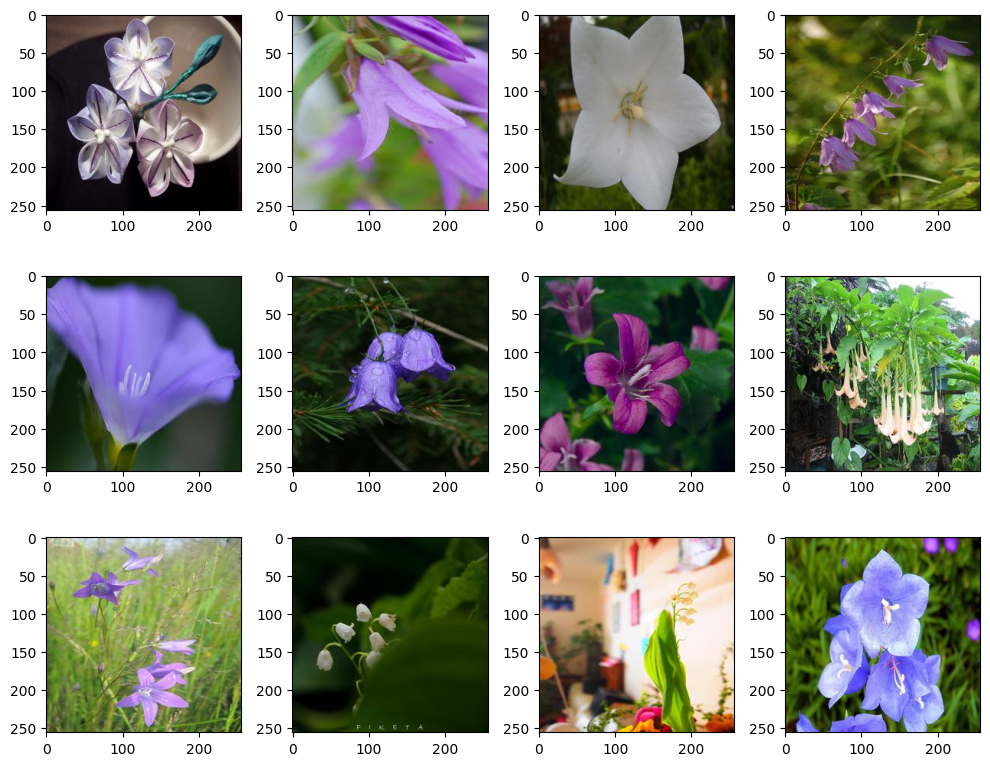

In [30]:
plt.figure(figsize = (10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
plt.tight_layout()

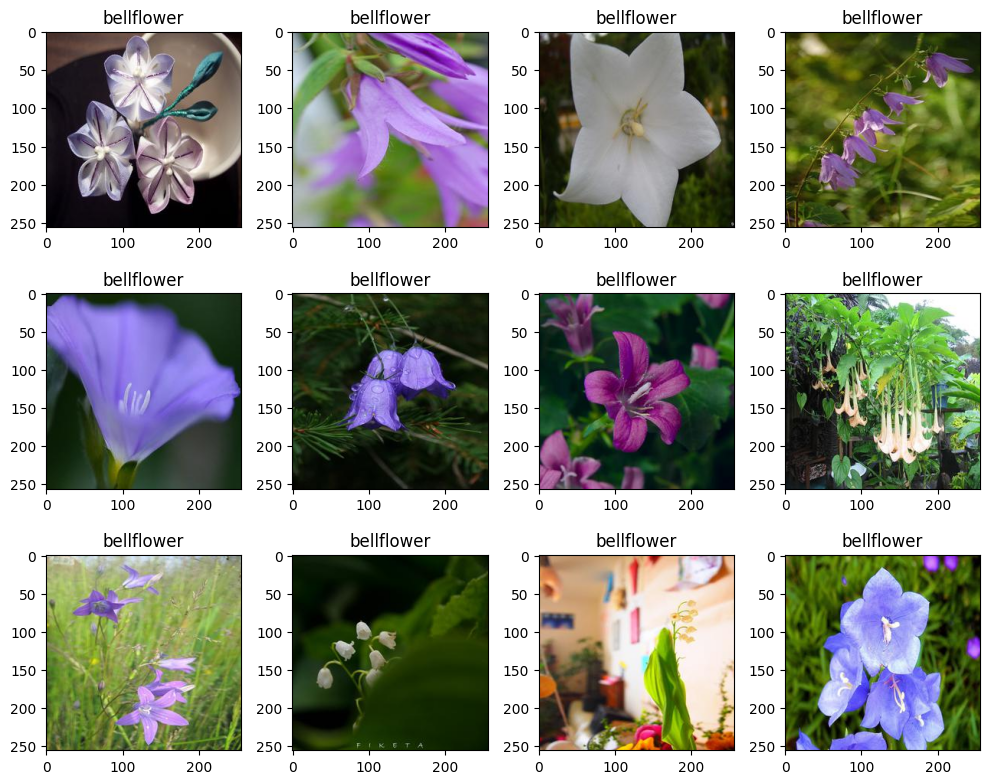

In [31]:
plt.figure(figsize = (10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    plt.title(label_names[label[i]])
plt.tight_layout()

In [32]:
image,label=shuffle(image,label)

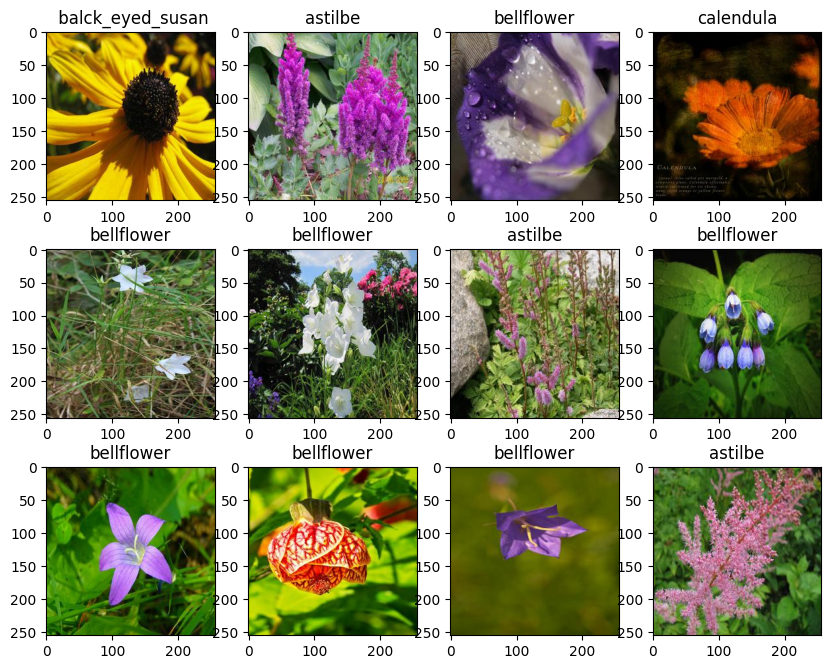

In [33]:
plt.figure(figsize=(10,8))
for i in range (12):
  plt.subplot(3,4,i+1)
  plt.imshow(image[i])
  plt.title(label_names[label[i]])

In [34]:
X = []

for i in image:
    X.append(resize(i, (500,500,3)))

In [35]:
X = np.array(X,dtype="uint8")
y= np.array(label)

In [36]:
X = np.array(X)
y= np.array(label)

In [37]:
d1, d2, d3, d4 = X.shape

In [38]:
X = X.reshape((d1, d2*d3*d4))

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [41]:
from sklearn.svm import SVC

In [42]:
model = SVC()

In [43]:
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [44]:
 y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
accuracy_score(y_test,y_pred)

0.3958333333333333

In [47]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.33      0.10      0.15        50
           1       0.38      0.94      0.54        63
           2       0.44      0.24      0.31        62
           3       0.44      0.25      0.32        65

    accuracy                           0.40       240
   macro avg       0.40      0.38      0.33       240
weighted avg       0.40      0.40      0.34       240

